**Objetivo del modelo:**
El objetivo del modelo es identificar los factores que influyen en la contratación de depósitos y evaluar su capacidad para priorizar clientes en campañas comerciales.

# 1. Importación librerías

In [42]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np


# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Preprocesamiento de datos y ML
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluacion
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.outliers_influence import variance_inflation_factor

import Funciones_TFM as fun

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# 2. Carga del dataset

In [43]:
df = pd.read_csv("dataset_modelo.csv")

In [44]:
# Transformación de la variable "y" a binaria
df['y_bin'] = df['y'].map({"no": 0, "yes": 1})

In [45]:
df["previous_group"] = df["previous_group"].astype(str).str.strip()

# 3. Selección inicial de variables

## 3.1 Análisis univariante (Cramer's V)

In [46]:
variables_a_analizar = [
    "age_group",
    "job",
    "education_group",
    "marital",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "campaign_group",
    "duration_group",
    "pdays_group",
    "previous_group",
     "poutcome",
]

tabla_resultados = fun.tabla_chi2_cramersv(
    df=df,
    target="y",
    variables=variables_a_analizar
)

tabla_resultados

,variable,chi2_p_value,cramers_v
11,duration_group,0.0000,0.344
12,pdays_group,0.0000,0.325
14,poutcome,0.0000,0.321
8,month,0.0000,0.275
13,previous_group,0.0000,0.236
0,age_group,0.0000,0.167
1,job,0.0000,0.153
7,contact,0.0000,0.145
4,default,0.0000,0.099
10,campaign_group,0.0000,0.066


**Conclusión:**

Aunque algunas variables presentan asociación estadísticamente significativa en el análisis univariante (Cramér’s V), su contribución marginal en el modelo multivariante fue limitada.

- `housing` y `loan` presentan asociación prácticamente nula (Cramer's V <0.02)
- `day_of_week` muestra una asociación muy débil y no mejora el rendimiento predictivo
- `default` aunque presenta asociación moderada en análisis univariante, presenta una distribución altamente desbalanceada, con un número extremadamente reducido de casos positivos. Esto puede generar estimaciones inestables y coeficientes poco robustos en el modelo.
- `duration` dado que la información de la variable solo está disponible una vez realizado el contacto, incluirla introduciría un sesgo temporal al utilizar información posterior al evento de decisión. El objetivo es mantener un enfoque realista de priorización previa al contacto.

Por ello se decidió eliminarlas para reducir la complejidad, mejorar la interpretabilidad y minimizar overfitting innecesario.

## 3.2 Multicolinealidad (macro)

In [52]:
# Análisis variables macroeconómicas
macro_cols = ["euribor3m", "emp.var.rate", "nr.employed", "cons.price.idx", "cons.conf.idx"]

# 1) Dataset solo con macros
X_macro = df[macro_cols].copy()

# 2) Limpieza: infinitos y NaNs (rellenamos con mediana para no perder filas)
X_macro = X_macro.replace([np.inf, -np.inf], np.nan)
X_macro = X_macro.fillna(X_macro.median(numeric_only=True))

# 3) Escalado (recomendado para estabilidad numérica)
scaler = StandardScaler()
X_macro_scaled = pd.DataFrame(
    scaler.fit_transform(X_macro),
    columns=macro_cols
)

# 4) Cálculo VIF (sin const, VIF se calcula entre features)
vif_df = pd.DataFrame({
    "feature": macro_cols,
    "VIF": [variance_inflation_factor(X_macro_scaled.values, i) for i in range(X_macro_scaled.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

,feature,VIF
0,euribor3m,63.860354
1,emp.var.rate,32.897863
2,nr.employed,30.743930
3,cons.price.idx,6.294354
4,cons.conf.idx,2.596859


In [55]:
# Media de variables macro por mes
macro_por_mes = df.groupby("month")[[
    "euribor3m",
    "emp.var.rate",
    "nr.employed",
    "cons.price.idx",
    "cons.conf.idx"
]].mean()

macro_por_mes

,euribor3m,emp.var.rate,nr.employed,cons.price.idx,cons.conf.idx
month,,,,,
apr,1.361047,-1.800000,5093.121437,93.119575,-46.273318
aug,4.300408,0.746940,5200.239330,93.311022,-35.597021
dec,0.865319,-2.846154,5031.895604,92.715363,-33.708791
jul,4.686026,1.159353,5214.089985,93.895109,-42.371209
jun,4.256908,0.688379,5197.493193,94.245402,-41.579428
mar,1.162745,-1.800000,5055.390110,93.097330,-42.650549
may,3.293696,-0.164945,5149.522242,93.528894,-40.579168
nov,3.723018,-0.418561,5173.025683,93.200944,-41.238561
oct,1.200762,-2.437238,5018.825662,93.176145,-34.591632


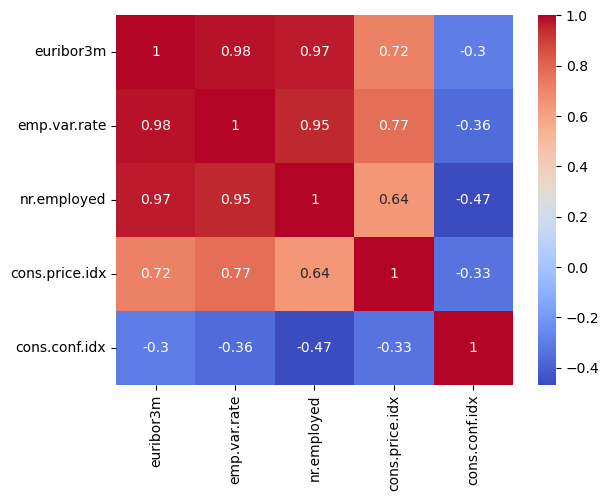

In [56]:
# Heatmap variables macroeconómicas con month
sns.heatmap(macro_por_mes.corr(), annot=True, cmap="coolwarm")
plt.show()

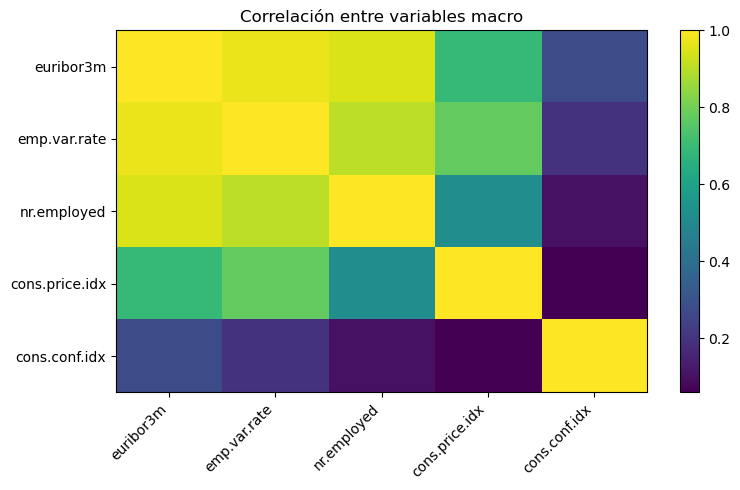

In [57]:
plt.figure(figsize=(8,5))
plt.imshow(corr_macro, aspect="auto")
plt.xticks(range(len(macro_cols)), macro_cols, rotation=45, ha="right")
plt.yticks(range(len(macro_cols)), macro_cols)
plt.colorbar()
plt.title("Correlación entre variables macro")
plt.tight_layout()
plt.show()

**Multicolinealidad (variables macroeconómicas)**

Se evaluó la colinealidad entre variables macro (`euribor3m`, `emp.var.rate`, `nr.employed`, `cons.price.idx`, `cons.conf.idx`) mediante **matriz de correlación y VIF**. 
Se observa una correlación extremadamente alta entre `euribor3m`, `emp.var.rate` y `nr.employed` **(r > 0.95)**, indicando redundancia informativa.

El análisis de VIF confirma multicolinealidad severa:
- `euribor3m`: VIF = 63.86
- `emp.var.rate`: VIF = 32.90
- `nr.employed`: VIF = 30.74

Dado que valores de VIF superiores a 10 indican colinealidad crítica, se decidió mantener únicamente `euribor3m` como proxy del entorno macroeconómico, eliminando el resto de variables macro para mejorar la estabilidad e interpretabilidad del modelo.

# 4. Preparación de los datos

## 4.1 Codificación

In [5]:
cols_modelo = [
    "y_bin",
    "age_group",
    "job",
    "marital",
    "education_group",
    "contact",
    "campaign_group",
    "poutcome",
    "month",
    "euribor3m"

]

df_model = df[cols_modelo].copy()

In [12]:
cat_cols = [
    "age_group",
    "campaign_group",
    "job",
    "marital",
    "month",
    "education_group",
    "contact",
    "poutcome",
]

# Convertimos las columnas categóricas a variables dummy
df_model_dum = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

## 4.2 Train / Test split

In [13]:
# Separamos variables (features) de la variable target y ("y")
X = df_model_dum.drop("y_bin", axis=1)
y = df_model_dum["y_bin"]

In [69]:
# Dividimos los datos en conjuntos de entrenamiento y test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4.3 Escalado

In [ ]:
num_cols = ["euribor3m"]

# Copias para evitar warnings
X_train = X_train.copy()
X_test  = X_test.copy()

# 1) Fillna: calcula la mediana SOLO en train
medianas = X_train[num_cols].median()

#X_train.loc[:, num_cols] = X_train[num_cols].fillna(medianas)
X_test.loc[:, num_cols]  = X_test[num_cols].fillna(medianas)  # usamos las medianas de train

# 2) Escalado: fit SOLO en train
scaler = StandardScaler()
X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols]  = scaler.transform(X_test[num_cols])

In [71]:
# Comparación: Baseline (class_weight) vs SMOTE
from imblearn.over_sampling import SMOTE

# 1) Baseline: Logistic Regression con class_weight balanced (sin SMOTE)
baseline = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
baseline.fit(X_train, y_train)

y_prob_test_base = baseline.predict_proba(X_test)[:, 1]
y_pred_test_base = (y_prob_test_base >= 0.5).astype(int)

auc_test_base = roc_auc_score(y_test, y_prob_test_base)

print("===== BASELINE (class_weight='balanced') =====")
print(f"AUC TEST: {auc_test_base:.4f}")
print(classification_report(y_test, y_pred_test_base))
print(confusion_matrix(y_test, y_pred_test_base))


# 2) SMOTE: oversampling SOLO en train
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_sm, y_train_sm)

y_prob_test_smote = smote_model.predict_proba(X_test)[:, 1]
y_pred_test_smote = (y_prob_test_smote >= 0.5).astype(int)

auc_test_smote = roc_auc_score(y_test, y_prob_test_smote)

print("\n===== SMOTE (solo en TRAIN) =====")
print(f"AUC TEST: {auc_test_smote:.4f}")
print(classification_report(y_test, y_pred_test_smote))
print(confusion_matrix(y_test, y_pred_test_smote))


# 3) Resumen comparativo rápido
print("\n===== RESUMEN =====")
print(f"AUC TEST Baseline: {auc_test_base:.4f}")
print(f"AUC TEST SMOTE   : {auc_test_smote:.4f}")

===== BASELINE (class_weight='balanced') =====
AUC TEST: 0.7939
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      7308
           1       0.33      0.68      0.44       928

    accuracy                           0.81      8236
   macro avg       0.64      0.75      0.66      8236
weighted avg       0.88      0.81      0.83      8236

[[6007 1301]
 [ 294  634]]

===== SMOTE (solo en TRAIN) =====
AUC TEST: 0.7714
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      7308
           1       0.30      0.63      0.40       928

    accuracy                           0.79      8236
   macro avg       0.62      0.72      0.64      8236
weighted avg       0.87      0.79      0.82      8236

[[5926 1382]
 [ 343  585]]

===== RESUMEN =====
AUC TEST Baseline: 0.7939
AUC TEST SMOTE   : 0.7714


# 5. Modelo

## 5.1 Regresión logística

In [72]:
# Creamos una instancia del modelo de regresión logística
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

# Entrenamos el modelo
log_reg.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

### 5.1.2 Classification report

In [73]:
# Entorno TEST
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("=== TEST ===")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

=== TEST ===
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      7308
           1       0.33      0.68      0.44       928

    accuracy                           0.81      8236
   macro avg       0.64      0.75      0.66      8236
weighted avg       0.88      0.81      0.83      8236

[[6007 1301]
 [ 294  634]]


In [74]:
# Probabilidades en TRAIN y TEST
y_prob_train = log_reg.predict_proba(X_train)[:, 1]
y_prob_test  = log_reg.predict_proba(X_test)[:, 1]

# AUC (siempre con probabilidades, no con y_pred)
auc_train = roc_auc_score(y_train, y_prob_train)
auc_test  = roc_auc_score(y_test, y_prob_test)

print(f"AUC TRAIN: {auc_train:.4f}")
print(f"AUC TEST : {auc_test:.4f}")

AUC TRAIN: 0.7890
AUC TEST : 0.7939


In [75]:
# Entorno TRAIN
y_pred_train = log_reg.predict(X_train)
y_prob_train = log_reg.predict_proba(X_train)[:, 1]

print("=== TRAIN ===")
print(classification_report(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))


=== TRAIN ===
              precision    recall  f1-score   support

           0       0.95      0.82      0.88     29229
           1       0.31      0.65      0.42      3711

    accuracy                           0.80     32940
   macro avg       0.63      0.73      0.65     32940
weighted avg       0.88      0.80      0.83     32940

[[23897  5332]
 [ 1297  2414]]


# 6. Análisis de umbrales

In [76]:
# Umbrales a probar
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25]

rows = []
for t in thresholds:
    y_pred_t = (y_prob_test >= t).astype(int)
    
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec  = recall_score(y_test, y_pred_t, zero_division=0)
    f1   = f1_score(y_test, y_pred_t, zero_division=0)
    acc  = accuracy_score(y_test, y_pred_t)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    rows.append({
        "threshold": t,
        "precision_1": prec,
        "recall_1": rec,
        "f1_1": f1,
        "accuracy": acc,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn
    })

results = pd.DataFrame(rows).sort_values("threshold", ascending=False)
results

,threshold,precision_1,recall_1,f1_1,accuracy,TP,FP,FN,TN
0,0.50,0.327649,0.683190,0.442892,0.806338,634,1301,294,6007
1,0.45,0.284197,0.720905,0.407678,0.763963,669,1685,259,5623
2,0.40,0.247059,0.746767,0.371283,0.715032,693,2112,235,5196
3,0.35,0.189703,0.806034,0.307124,0.590214,748,3195,180,4113
4,0.30,0.148209,0.878233,0.253618,0.417557,815,4684,113,2624
5,0.25,0.134188,0.936422,0.234738,0.312045,869,5607,59,1701


# 7. Evaluación de técnicas de balanceo

## 7.1 Comparación baseline vs SMOTE

In [122]:
# Comparación: Baseline (class_weight) vs SMOTE
from imblearn.over_sampling import SMOTE

# 1) Baseline: Logistic Regression con class_weight balanced (sin SMOTE)
baseline = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
baseline.fit(X_train, y_train)

y_prob_test_base = baseline.predict_proba(X_test)[:, 1]
y_pred_test_base = (y_prob_test_base >= 0.5).astype(int)

auc_test_base = roc_auc_score(y_test, y_prob_test_base)

print("===== BASELINE (class_weight='balanced') =====")
print(f"AUC TEST: {auc_test_base:.4f}")
print(classification_report(y_test, y_pred_test_base))
print(confusion_matrix(y_test, y_pred_test_base))


# 2) SMOTE: oversampling SOLO en train
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_sm, y_train_sm)

y_prob_test_smote = smote_model.predict_proba(X_test)[:, 1]
y_pred_test_smote = (y_prob_test_smote >= 0.5).astype(int)

auc_test_smote = roc_auc_score(y_test, y_prob_test_smote)

print("\n===== SMOTE (solo en TRAIN) =====")
print(f"AUC TEST: {auc_test_smote:.4f}")
print(classification_report(y_test, y_pred_test_smote))
print(confusion_matrix(y_test, y_pred_test_smote))


# 3) Resumen comparativo rápido
print("\n===== RESUMEN =====")
print(f"AUC TEST Baseline: {auc_test_base:.4f}")
print(f"AUC TEST SMOTE   : {auc_test_smote:.4f}")

===== BASELINE (class_weight='balanced') =====
AUC TEST: 0.7939
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      7308
           1       0.33      0.68      0.44       928

    accuracy                           0.81      8236
   macro avg       0.64      0.75      0.66      8236
weighted avg       0.88      0.81      0.83      8236

[[6007 1301]
 [ 294  634]]

===== SMOTE (solo en TRAIN) =====
AUC TEST: 0.7714
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      7308
           1       0.30      0.63      0.40       928

    accuracy                           0.79      8236
   macro avg       0.62      0.72      0.64      8236
weighted avg       0.87      0.79      0.82      8236

[[5926 1382]
 [ 343  585]]

===== RESUMEN =====
AUC TEST Baseline: 0.7939
AUC TEST SMOTE   : 0.7714


# 8. Interpretación de coeficientes

## 8.1 Coeficientes y odds

In [78]:
# Coeficientes y odds
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef_log_odds": log_reg.coef_[0]
})

coef_df["odds_ratio"] = np.exp(coef_df["coef_log_odds"])

coef_df = coef_df.sort_values(by="coef_log_odds", ascending=False)

coef_df.head(10)

,feature,coef_log_odds,odds_ratio
37,poutcome_success,1.994752,7.350378
27,month_mar,1.157485,3.181921
30,month_oct,1.084353,2.957526
24,month_dec,0.810914,2.249965
31,month_sep,0.521161,1.683982
25,month_jul,0.462788,1.588496
36,poutcome_nonexistent,0.399769,1.491480
4,age_group_66+,0.397952,1.488772
26,month_jun,0.314706,1.369857
23,month_aug,0.264204,1.302394


## 8.2 Tabla factores top positivos

In [79]:
# Factores que empujan al YES
top_yes = coef_df[coef_df["coef_log_odds"] > 0].head(25)
top_yes

,feature,coef_log_odds,odds_ratio
37,poutcome_success,1.994752,7.350378
27,month_mar,1.157485,3.181921
30,month_oct,1.084353,2.957526
24,month_dec,0.810914,2.249965
31,month_sep,0.521161,1.683982
25,month_jul,0.462788,1.588496
36,poutcome_nonexistent,0.399769,1.491480
4,age_group_66+,0.397952,1.488772
26,month_jun,0.314706,1.369857
23,month_aug,0.264204,1.302394


## 8.3 Tabla factores top negativos

In [80]:
# Factores que empujan al NO
top_no = coef_df[coef_df["coef_log_odds"] < 0].sort_values(by="coef_log_odds").head(30)
top_no

,feature,coef_log_odds,odds_ratio
0,euribor3m,-0.777481,0.459562
28,month_may,-0.563931,0.568968
8,campaign_group_4+,-0.242020,0.785041
18,job_unemployed,-0.185638,0.830574
9,job_blue-collar,-0.152294,0.858736
1,age_group_36-45,-0.132792,0.875647
15,job_services,-0.129888,0.878194
32,education_group_low_education,-0.125680,0.881897
33,education_group_medium_education,-0.099734,0.905078
35,contact_telephone,-0.096166,0.908313


# 9. Análisis de priorización

## 9.1 Deciles

In [81]:
df_scores = X_test.copy()
df_scores["prob"] = y_prob
df_scores["real"] = y_test.values

df_scores["decile"] = pd.qcut(df_scores["prob"], 10, labels=False)

lift_table = df_scores.groupby("decile").agg(
    n=("real", "count"),
    conv=("real", "mean"),
    proba_mean=("prob", "mean")
).reset_index()

global_rate = df_scores["real"].mean()
lift_table["lift_vs_global"] = lift_table["conv"] / global_rate

lift_table.sort_values("decile", ascending=False)

,decile,n,conv,proba_mean,lift_vs_global
9,9,824,0.470874,0.854650,4.179005
8,8,823,0.257594,0.638897,2.286148
7,7,823,0.087485,0.486102,0.776428
6,6,824,0.061893,0.396725,0.549302
5,5,824,0.042476,0.358038,0.376972
4,4,823,0.041312,0.331952,0.366646
3,3,823,0.058323,0.304866,0.517618
2,2,824,0.040049,0.269208,0.355431
1,1,823,0.027947,0.178579,0.248026
0,0,825,0.038788,0.138292,0.344242


In [82]:
# 1) Base con verdad y probabilidad
df_rank = pd.DataFrame({
    "y_true": y_test.values if hasattr(y_test, "values") else y_test,
    "prob": y_prob_test
}).sort_values("prob", ascending=False).reset_index(drop=True)

total_clientes = len(df_rank)
total_conv = df_rank["y_true"].sum()
conv_global = total_conv / total_clientes

# 2) Crear deciles (Top decil = 10, peor decil = 1)
df_rank["decil"] = pd.qcut(df_rank.index, 10, labels=False)  # 0..9 (0 = top)
df_rank["decil"] = 10 - df_rank["decil"]                    # 10..1 (10 = top)

# 3) Métricas por decil (no acumuladas)
por_decil = (
    df_rank.groupby("decil")
    .agg(
        clientes=("y_true", "count"),
        contrataciones=("y_true", "sum"),
        prob_media=("prob", "mean"),
    )
    .sort_index(ascending=False)  # 10 -> 1
)

por_decil["tasa_conversion"] = por_decil["contrataciones"] / por_decil["clientes"]
por_decil["lift_vs_global"] = por_decil["tasa_conversion"] / conv_global

# 4) Acumulados desde el TOP hacia abajo
por_decil["clientes_acum"] = por_decil["clientes"].cumsum()
por_decil["contrataciones_acum"] = por_decil["contrataciones"].cumsum()

# 5) Porcentajes acumulados
por_decil["%base_contactada_acum"] = por_decil["clientes_acum"] / total_clientes
por_decil["%contrataciones_capturadas_acum"] = por_decil["contrataciones_acum"] / total_conv

# 6) Extras útiles para lectura
por_decil["conversion_global"] = conv_global
por_decil["%conversion_decil"] = por_decil["tasa_conversion"]  # alias más claro

# 7) Renombrar columnas para dashboard (clarito)
df_dashboard = por_decil.reset_index().rename(columns={
    "decil": "Decil (10=Top)",
    "clientes": "Clientes (decil)",
    "contrataciones": "Contrataciones (decil)",
    "tasa_conversion": "Conversión (decil)",
    "prob_media": "Prob. media (decil)",
    "lift_vs_global": "Lift vs global (decil)",
    "clientes_acum": "Clientes acumulados (Top→)",
    "contrataciones_acum": "Contrataciones acumuladas (Top→)",
    "%base_contactada_acum": "% base contactada (acum)",
    "%contrataciones_capturadas_acum": "% contrataciones capturadas (acum)",
    "conversion_global": "Conversión global"
})

df_dashboard

,Decil (10=Top),Clientes (decil),Contrataciones (decil),Prob. media (decil),Conversión (decil),Lift vs global (decil),Clientes acumulados (Top→),Contrataciones acumuladas (Top→),% base contactada (acum),% contrataciones capturadas (acum),Conversión global,%conversion_decil
0,10,824,388,0.854650,0.470874,4.179005,824,388,0.100049,0.418103,0.112676,0.470874
1,9,824,212,0.638782,0.257282,2.283374,1648,600,0.200097,0.646552,0.112676,0.257282
2,8,823,72,0.485964,0.087485,0.776428,2471,672,0.300024,0.724138,0.112676,0.087485
3,7,824,51,0.396655,0.061893,0.549302,3295,723,0.400073,0.779095,0.112676,0.061893
4,6,823,35,0.358019,0.042527,0.377430,4118,758,0.500000,0.816810,0.112676,0.042527
5,5,824,34,0.331937,0.041262,0.366201,4942,792,0.600049,0.853448,0.112676,0.041262
6,4,823,48,0.304829,0.058323,0.517618,5765,840,0.699976,0.905172,0.112676,0.058323
7,3,824,33,0.269138,0.040049,0.355431,6589,873,0.800024,0.940733,0.112676,0.040049
8,2,823,23,0.178486,0.027947,0.248026,7412,896,0.899951,0.965517,0.112676,0.027947
9,1,824,32,0.138272,0.038835,0.344660,8236,928,1.000000,1.000000,0.112676,0.038835


In [83]:
# Tabla de escenarios Top X% (acumulado)
escenarios = [0.05, 0.10, 0.15, 0.20, 0.30]

rows = []
for p in escenarios:
    k = int(np.ceil(total_clientes * p))
    top = df_rank.head(k)
    conv_top = top["y_true"].mean()
    capturadas = top["y_true"].sum()
    pct_capturadas = capturadas / total_conv
    lift = conv_top / conv_global

    rows.append({
        "Escenario": f"Top {int(p*100)}%",
        "Clientes contactados": k,
        "% base contactada": k / total_clientes,
        "Conversión en el grupo": conv_top,
        "Lift vs global": lift,
        "Contrataciones capturadas": int(capturadas),
        "% contrataciones capturadas": pct_capturadas
    })

df_escenarios = pd.DataFrame(rows)
df_escenarios

,Escenario,Clientes contactados,% base contactada,Conversión en el grupo,Lift vs global,Contrataciones capturadas,% contrataciones capturadas
0,Top 5%,412,0.050024,0.560680,4.976032,231,0.248922
1,Top 10%,824,0.100049,0.470874,4.179005,388,0.418103
2,Top 15%,1236,0.150073,0.435275,3.863066,538,0.579741
3,Top 20%,1648,0.200097,0.364078,3.231189,600,0.646552
4,Top 30%,2471,0.300024,0.271955,2.413598,672,0.724138


# 10. Preparación de dataframes para el Dashboard

In [88]:
# 1) Nos quedamos SOLO con las filas de test (mismo orden que y_test)
df_scored = X.loc[y_test.index].copy()

# 2) Añadimos verdad y probabilidad
df_scored["y_true"] = y_test.values if hasattr(y_test, "values") else y_test
df_scored["prob"]   = y_prob_test

# 3) Ordenamos por prob desc (Top primero)
df_scored = df_scored.sort_values("prob", ascending=False).reset_index(drop=False)
df_scored.rename(columns={"index":"row_id"}, inplace=True)

df_scored.head()

,row_id,euribor3m,age_group_36-45,age_group_46-55,age_group_56-65,age_group_66+,age_group_<=25,campaign_group_2,campaign_group_3,campaign_group_4+,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,marital_unknown,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,education_group_low_education,education_group_medium_education,education_group_unknown,contact_telephone,poutcome_nonexistent,poutcome_success,y_true,prob
0,39319,0.639,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,True,0,0.987265
1,39122,0.655,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,1,0.986777
2,38168,0.752,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,1,0.985664
3,39135,0.655,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,1,0.985501
4,38304,0.740,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,1,0.985370


In [121]:
# ============================================================
# PERFIL CLIENTE (TEST) PARA LOOKER
# - Scores + y_true
# - Percentile/Rank
# - Flags acumulados (in_top_5/10/15/20/30)
# - scenario_band (no acumulado) solo informativo
# - decil_10_top (10=mejor)
# - Variables "humanas" (grupo_edad, job, education, marital, month, contact, poutcome, campaign_group)
# - Reconstruye categorías BASE cuando se usó get_dummies(drop_first=True)
# ============================================================

import numpy as np
import pandas as pd


# ------------- 1) Helper robusto: one-hot -> etiqueta con BASE -------------
def onehot_to_label_with_base(
    df: pd.DataFrame,
    prefix: str,
    base_label: str,
    out_col: str | None = None,
    default_if_missing: str = "Sin clasificar",
) -> pd.DataFrame:
    """
    Convierte columnas one-hot con un prefijo (p.ej. 'job_') en una sola columna etiqueta.
    - Si ninguna dummy está activa => asigna base_label (categoría base de drop_first)
    - Soporta bool, 0/1, y strings "True"/"False"/"1"/"0"
    - Si no hay columnas con ese prefijo => deja default_if_missing
    """
    cols = [c for c in df.columns if c.startswith(prefix)]
    if out_col is None:
        out_col = prefix[:-1]  # 'job_' -> 'job'

    if not cols:
        df[out_col] = default_if_missing
        return df

    tmp = df[cols].copy()

    # Normalizamos a 0/1 (por si vienen como bool o texto)
    tmp = tmp.replace(
        {
            True: 1,
            False: 0,
            "True": 1,
            "False": 0,
            "TRUE": 1,
            "FALSE": 0,
            "1": 1,
            "0": 0,
        }
    )
    tmp = tmp.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

    labels = [c.replace(prefix, "") for c in cols]

    # Si hay alguna dummy activa, elegimos la primera (por orden de columnas)
    has_any = (tmp.sum(axis=1) > 0).values
    idx = tmp.values.argmax(axis=1)
    chosen = np.array([labels[i] for i in idx], dtype=object)

    df[out_col] = np.where(has_any, chosen, base_label)
    return df


# ------------- 2) Builder principal -------------
def build_profile_test_df(
    X: pd.DataFrame,
    y_test,
    y_prob_test,
    keep_dummies: bool = False,
    # Percentiles acumulados que usarás como escenarios
    top_list=(0.05, 0.10, 0.15, 0.20, 0.30),
    # Categorías base (ajusta si en tu pipeline cambiaste drop_first)
    base_map=None,
):
    """
    Devuelve un DF a nivel fila (solo TEST) listo para Looker con:
    - y_true, prob, rank, percentile
    - in_top_* acumulados
    - scenario_band NO acumulado (solo informativo)
    - decil_10_top (10=mejor)
    - etiquetas humanas con base reconstruida
    """
    if base_map is None:
        # IMPORTANTÍSIMO: estas bases son las que te faltaban en gráficos.
        # Ajusta si tu preprocesado eligió otra referencia.
        base_map = {
            "age_group_": "26-35",                 # si 26-35 fue la categoría base
            "job_": "admin.",                      # base job
            "education_group_": "high_education",  # base education_group
            "marital_": "divorced",                # base marital típica en bank
            "month_": "apr",                       # base month típica en bank
            "contact_": "cellular",                # si solo tienes contact_telephone
            "poutcome_": "failure",                # base poutcome típica en bank
        }

    # 1) SOLO TEST (mismo orden que y_test)
    df = X.loc[y_test.index].copy()

    # 2) y_true y prob
    y_true = y_test.values if hasattr(y_test, "values") else np.array(y_test)
    df["y_true"] = y_true.astype(int)
    df["prob"] = np.asarray(y_prob_test).astype(float)

    # 3) Ordenar por score desc (Top primero)
    df = df.sort_values("prob", ascending=False).reset_index(drop=False)
    df.rename(columns={"index": "row_id"}, inplace=True)

    # 4) Rank y percentile
    n = len(df)
    df["rank"] = np.arange(1, n + 1)
    df["percentile"] = df["rank"] / n  # (0,1]

    # 5) Flags acumulados TopK
    for p in top_list:
        col = f"in_top_{int(p*100)}"
        df[col] = df["percentile"] <= p

    # Si quieres nombres exactos in_top_5, in_top_10... (compatibilidad con lo que ya usas en Looker)
    # (Los renombramos para que siempre existan)
    rename_map = {
        "in_top_5": "in_top_5",
        "in_top_10": "in_top_10",
        "in_top_15": "in_top_15",
        "in_top_20": "in_top_20",
        "in_top_30": "in_top_30",
    }
    # Crear/asegurar columnas estándar
    df["in_top_5"] = df.get("in_top_5", df["percentile"] <= 0.05)
    df["in_top_10"] = df.get("in_top_10", df["percentile"] <= 0.10)
    df["in_top_15"] = df.get("in_top_15", df["percentile"] <= 0.15)
    df["in_top_20"] = df.get("in_top_20", df["percentile"] <= 0.20)
    df["in_top_30"] = df.get("in_top_30", df["percentile"] <= 0.30)

    # 5b) scenario_band (NO acumulado) solo informativo:
    # ojo: esto NO es "acumulado", es el primer umbral que cumple.
    conditions = [
        df["percentile"] <= 0.05,
        (df["percentile"] > 0.05) & (df["percentile"] <= 0.10),
        (df["percentile"] > 0.10) & (df["percentile"] <= 0.15),
        (df["percentile"] > 0.15) & (df["percentile"] <= 0.20),
        (df["percentile"] > 0.20) & (df["percentile"] <= 0.30),
    ]
    choices = ["Top 5%", "Top 10%", "Top 15%", "Top 20%", "Top 30%"]
    df["scenario_band"] = np.select(conditions, choices, default="Resto")

    # 6) Decil 10 = mejor (por score)
    # qcut puede colapsar bins si hay muchos empates -> duplicates="drop"
    dec = pd.qcut(df["prob"], 10, labels=False, duplicates="drop") + 1
    df["decil_10_top"] = 11 - dec

    # 7) Etiquetas "humanas" (reconstruyendo base)
    # --- Edad
    # Si ya traes 'grupo_edad' en X, la mantenemos, pero rellenamos base si venía como "Sin clasificar"
    if "grupo_edad" in df.columns:
        df["grupo_edad"] = (
            df["grupo_edad"]
            .fillna(base_map["age_group_"])
            .replace("Sin clasificar", base_map["age_group_"])
        )
    else:
        # Reconstruimos desde dummies age_group_*
        df = onehot_to_label_with_base(
            df, "age_group_", base_label=base_map["age_group_"], out_col="grupo_edad"
        )

    # --- Job, marital, month, education_group, poutcome, contact
    df = onehot_to_label_with_base(df, "job_", base_label=base_map["job_"], out_col="job")
    df = onehot_to_label_with_base(df, "marital_", base_label=base_map["marital_"], out_col="marital")
    df = onehot_to_label_with_base(df, "month_", base_label=base_map["month_"], out_col="month")
    df = onehot_to_label_with_base(df, "education_group_", base_label=base_map["education_group_"], out_col="education_group")
    df = onehot_to_label_with_base(df, "poutcome_", base_label=base_map["poutcome_"], out_col="poutcome")
    df = onehot_to_label_with_base(df, "contact_", base_label=base_map["contact_"], out_col="contact")

    # --- Campaign group (tus columnas: campaign_group_2, _3, _4+)
    camp_cols = [c for c in df.columns if c.startswith("campaign_group_")]
    if camp_cols:
        df["campaign_group"] = "1"  # base implícita: group_1 si todas False
        for c in camp_cols:
            label = c.replace("campaign_group_", "")
            # soporta bool / 0/1 / texto
            vals = df[c].replace({True: 1, False: 0, "True": 1, "False": 0, "TRUE": 1, "FALSE": 0, "1": 1, "0": 0})
            vals = pd.to_numeric(vals, errors="coerce").fillna(0).astype(int)
            df.loc[vals == 1, "campaign_group"] = label
    else:
        df["campaign_group"] = "unknown"

    # 8) Limpiar dummies para Looker (recomendado)
    if not keep_dummies:
        drop_prefixes = [
            "age_group_",
            "job_",
            "marital_",
            "month_",
            "education_group_",
            "poutcome_",
            "contact_",
            "campaign_group_",
        ]
        drop_cols = []
        for p in drop_prefixes:
            drop_cols += [c for c in df.columns if c.startswith(p)]
        df = df.drop(columns=list(set(drop_cols)), errors="ignore")

    # 9) Orden útil de columnas (opcional)
    # (para que al exportar te queden primero las más importantes)
    preferred = [
        "row_id", "prob", "y_true", "rank", "percentile",
        "in_top_5", "in_top_10", "in_top_15", "in_top_20", "in_top_30",
        "scenario_band", "decil_10_top",
        "grupo_edad", "job", "education_group", "marital", "month", "contact", "poutcome", "campaign_group",
    ]
    cols = preferred + [c for c in df.columns if c not in preferred]
    df = df[cols]

    return df


# ------------- 3) Ejecutar y exportar -------------
# keep_dummies=False => ideal para Looker (solo columnas "humanas" + scores + flags)
df_profile_test = build_profile_test_df(X, y_test, y_prob_test, keep_dummies=False)

# Checks rápidos: no debería quedar "Sin clasificar" en variables clave (salvo que falte info real)
cols_check = ["grupo_edad", "job", "education_group", "marital", "month", "contact", "poutcome", "campaign_group"]
for c in cols_check:
    if c in df_profile_test.columns:
        print(c, "Sin clasificar ->", (df_profile_test[c] == "Sin clasificar").sum())

# Export
df_profile_test.to_csv("modelo_perfil_cliente.csv", index=False)
print("Exportado:", df_profile_test.shape, "-> modelo_perfil_cliente.csv")

grupo_edad Sin clasificar -> 0
job Sin clasificar -> 0
education_group Sin clasificar -> 0
marital Sin clasificar -> 0
month Sin clasificar -> 0
contact Sin clasificar -> 0
poutcome Sin clasificar -> 0
campaign_group Sin clasificar -> 0
Exportado: (8236, 21) -> modelo_perfil_cliente.csv


In [109]:
df_scored["percentile"].min(), df_scored["percentile"].max()

(0.00012141816415735794, 1.0)

In [27]:
coef_df.to_csv("modelo_completo_coeficientes.csv", index=False)


In [28]:
# Classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# AUC
auc = roc_auc_score(y_test, y_prob)

# Especificidad
specificity = tn / (tn + fp)

metricas_df = pd.DataFrame({
    "metric": [
        "accuracy",
        "precision_yes",
        "recall_yes",
        "f1_yes",
        "specificity",
        "auc",
        "true_negatives",
        "false_positives",
        "false_negatives",
        "true_positives"
    ],
    "value": [
        report["accuracy"],
        report["1"]["precision"],
        report["1"]["recall"],
        report["1"]["f1-score"],
        specificity,
        auc,
        tn,
        fp,
        fn,
        tp
    ]
})

metricas_df.to_csv("modelo_completo_metricas_test.csv", index=False)

metricas_df

,metric,value
0,accuracy,0.806338
1,precision_yes,0.327649
2,recall_yes,0.683190
3,f1_yes,0.442892
4,specificity,0.821976
5,auc,0.793944
6,true_negatives,6007.000000
7,false_positives,1301.000000
8,false_negatives,294.000000
9,true_positives,634.000000


In [62]:
# Exportar a CSV para el dashboard
df_escenarios.to_csv("dashboard_escenarios.csv", index=False)
df_dashboard.to_csv("dashboard_deciles.csv", index=False)

print("Generados: dashboard_escenarios.csv y dashboard_deciles.csv")

Generados: dashboard_escenarios.csv y dashboard_deciles.csv


In [63]:
metricas_df.to_csv("modelo_completo_metricas.csv", index=False)